In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns  

In [2]:
df = pd.read_csv('Zomato data .csv')
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [3]:
df.shape

(148, 7)

In [4]:
#change data type
def handleRate(value):
    value=str(value).split('/')
    value = value[0]
    return float(value)
df['rate']=df['rate'].apply(handleRate)
print(df.head())


                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [5]:
df.isna().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [7]:
# type of resturant
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'type of rasturant')

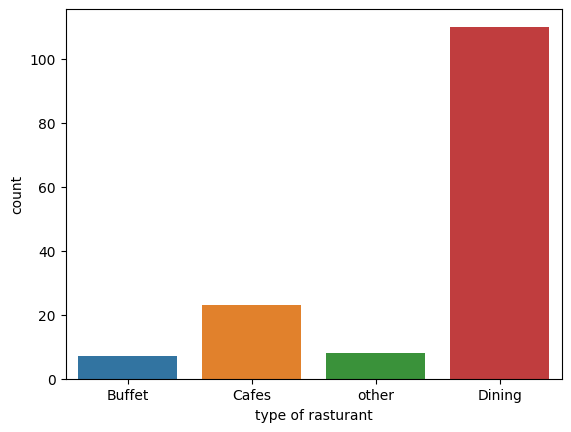

In [8]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("type of rasturant")

Text(0, 0.5, 'votes')

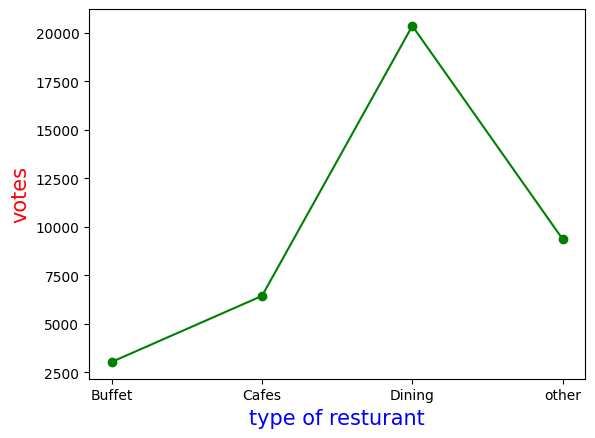

In [9]:
grouped_Data = df.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':grouped_Data})
plt.plot(result,c='green',marker='o')
plt.xlabel("type of resturant",c='blue',size=15)
plt.ylabel("votes",c='red',size=15)



In [10]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


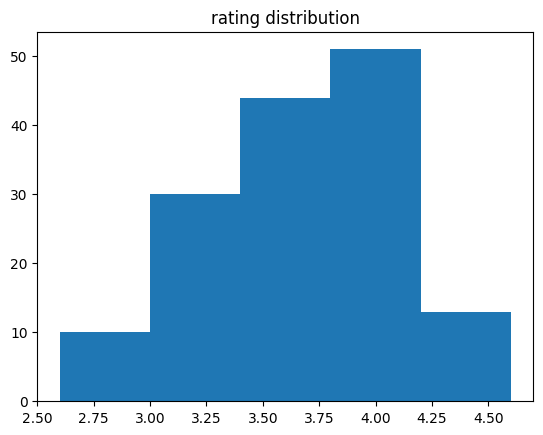

In [11]:
plt.hist(df['rate'],bins=5)
plt.title("rating distribution")
plt.show()

### conclusion - the majority resturants recieved rating from 3.5 to 4

Text(0.5, 0, 'approx_cost(for two people)')

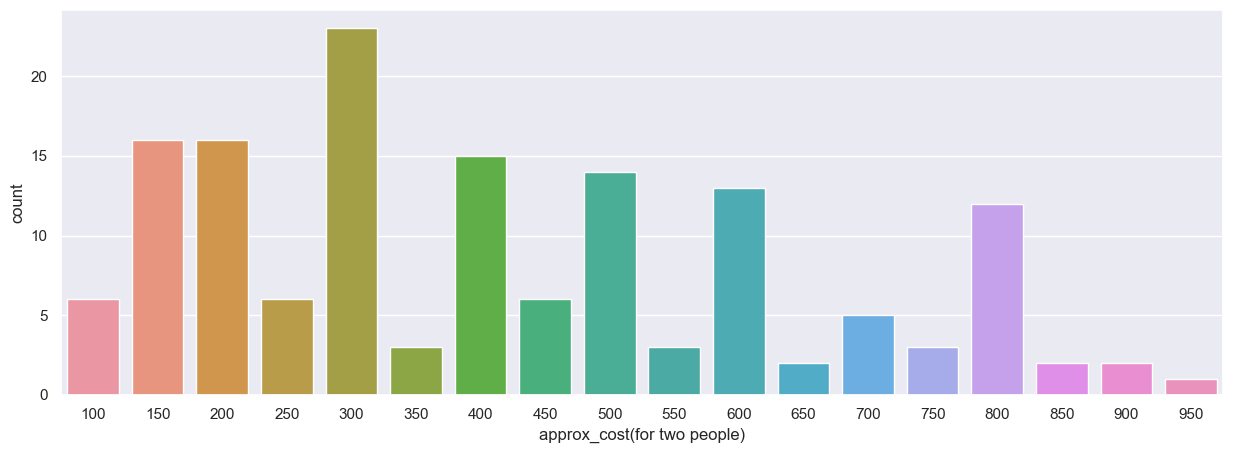

In [12]:
## average order spending by couple
sns.set(rc={'figure.figsize':(15,5)})
sns.countplot(x=df['approx_cost(for two people)'])
plt.xlabel("approx_cost(for two people)")

## conclusion - the majority of couple preferr resutants with an approximate cost of 300 rupees

<Axes: xlabel='online_order', ylabel='rate'>

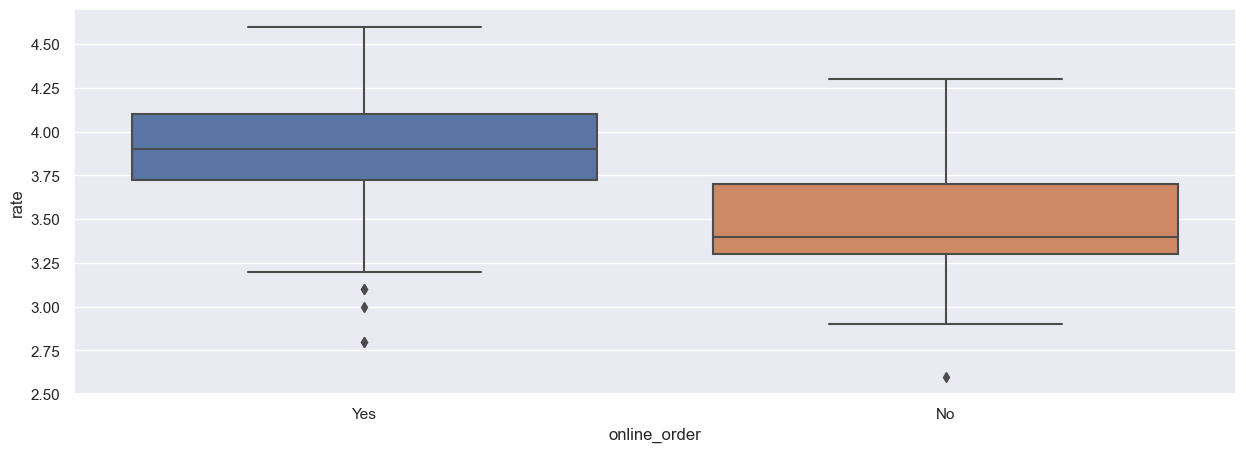

In [13]:
## which modes receives maximum rating
plt.Figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rate',data=df)

## conclusion - offline order recevied lower rating in comparision to online order

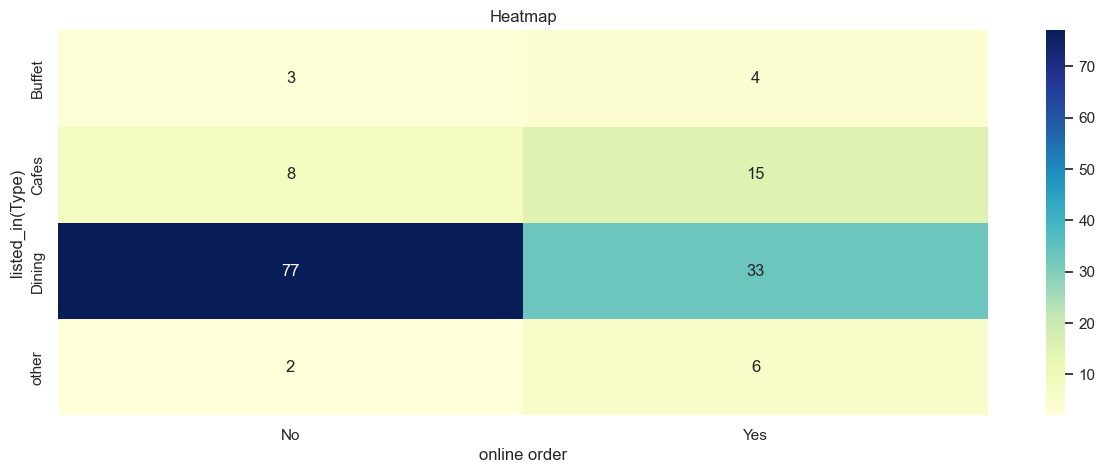

In [14]:
pivot_table = df.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table,annot=True,cmap='YlGnBu',fmt='d')
plt.title('Heatmap')
plt.xlabel('online order')
plt.ylabel('listed_in(Type)')
plt.show()

### Conclusion - Dining resturant primariliy accept offline order.whereas cafes primarily receive online orders.this suggets that client preferr to orders in person at resturants,but prefer online ordering at cafes.